# 12 Final Recommendations

## Purpose

This notebook summarizes the final results of the Houston Transit Investment Analysis project.

The goal is to combine the major outputs from previous notebooks — ridership, scheduled service, productivity, investment score, population density, and route geography — into a concise set of findings and recommendations.

## Primary Research Question

Are Houston METRO's transit resources aligned with areas of greatest ridership demand and population density, and which corridors appear strongest for future investment?

## Inputs

- `data/processed/route_investment_metrics.csv`
- `data/processed/key_route_geometry.csv`
- `data/processed/harris_tracts_density.geojson`

## Outputs

- Final route investment ranking
- Investment priority visualization
- Population density and route overlay map
- Final recommendations for future analysis and investment consideration

## Why This Matters

Transit agencies operate with limited resources. This final notebook translates technical analysis into decision-support insights that could be used by planners, analysts, or policymakers when evaluating where future service improvements or capital investments may produce the greatest benefit.


## 1. Load Final Analysis Datasets

This section loads the processed datasets created throughout the project. These files represent the final analytical inputs used to generate rankings, visualizations, and recommendations.

In [3]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

investment = pd.read_csv("../data/processed/route_investment_metrics.csv")
route_geometry = pd.read_csv("../data/processed/key_route_geometry.csv")
tracts = gpd.read_file("../data/processed/harris_tracts_density.geojson")

investment["investment_score"] = (
    investment["avg_weekday_boardings"] *
    investment["riders_per_trip"]
)

investment.head()

,route_long_name,route_type,route_text_color,route_color,agency_id,route_id,route_url,route_desc,route_short_name,avg_weekday_boardings,scheduled_trips,riders_per_trip,investment_score
0,Richmond,3,FFFFFF,4080,HOU,25,https://assets-cdn-prod.azureedge.us/assets/do...,NaN,25,7489,942.0,7.950106,59538.345011
1,Gessner,3,FFFFFF,4080,HOU,46,https://assets-cdn-prod.azureedge.us/assets/do...,NaN,46,7670,854.0,8.981265,68886.299766
2,Westheimer,3,FFFFFF,4080,HOU,82,https://assets-cdn-prod.azureedge.us/assets/do...,NaN,82,14054,1487.0,9.451244,132827.784802
3,Bellaire,3,FFFFFF,4080,HOU,2,https://assets-cdn-prod.azureedge.us/assets/do...,NaN,2,7590,1013.0,7.492596,56868.805528
4,Beechnut,3,FFFFFF,4080,HOU,4,https://assets-cdn-prod.azureedge.us/assets/do...,NaN,4,8743,896.0,9.757812,85312.554688


## 2. Confirm Investment Score

The investment score combines ridership demand and service productivity. This step ensures that the score exists in the final dataset before producing rankings or visualizations.

In [4]:
investment[
    [
        "route_long_name",
        "avg_weekday_boardings",
        "scheduled_trips",
        "riders_per_trip",
        "investment_score"
    ]
].sort_values("investment_score", ascending=False)

,route_long_name,avg_weekday_boardings,scheduled_trips,riders_per_trip,investment_score
2,Westheimer,14054,1487.0,9.451244,132827.784802
4,Beechnut,8743,896.0,9.757812,85312.554688
1,Gessner,7670,854.0,8.981265,68886.299766
0,Richmond,7489,942.0,7.950106,59538.345011
3,Bellaire,7590,1013.0,7.492596,56868.805528


## 6. Save Final Outputs

Final charts or processed datasets are saved for use in the project README, GitHub repository, and future interactive website.

In [5]:
investment.to_csv(
    "../data/processed/route_investment_metrics.csv",
    index=False
)

print("saved")

saved


## 4. Investment Priority Visualization

This bar chart communicates the final route ranking in a format that is easier for non-technical audiences to interpret.

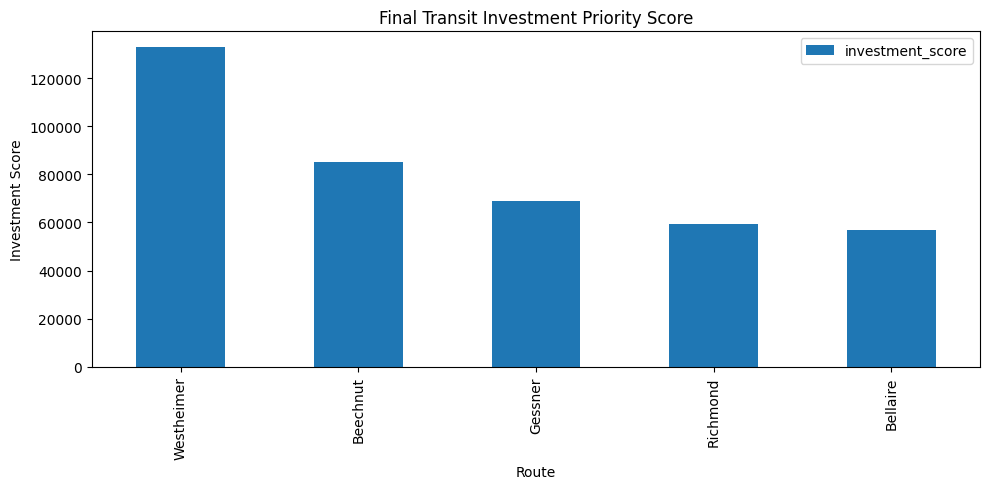

In [6]:
investment.sort_values(
    "investment_score",
    ascending=False
).plot(
    x="route_long_name",
    y="investment_score",
    kind="bar",
    figsize=(10,5)
)

plt.title("Final Transit Investment Priority Score")
plt.ylabel("Investment Score")
plt.xlabel("Route")
plt.tight_layout()
plt.show()

## 5. Population Density and Route Geography

This map overlays selected high-ridership METRO routes on top of Harris County population density. It provides geographic context for the final investment recommendations.

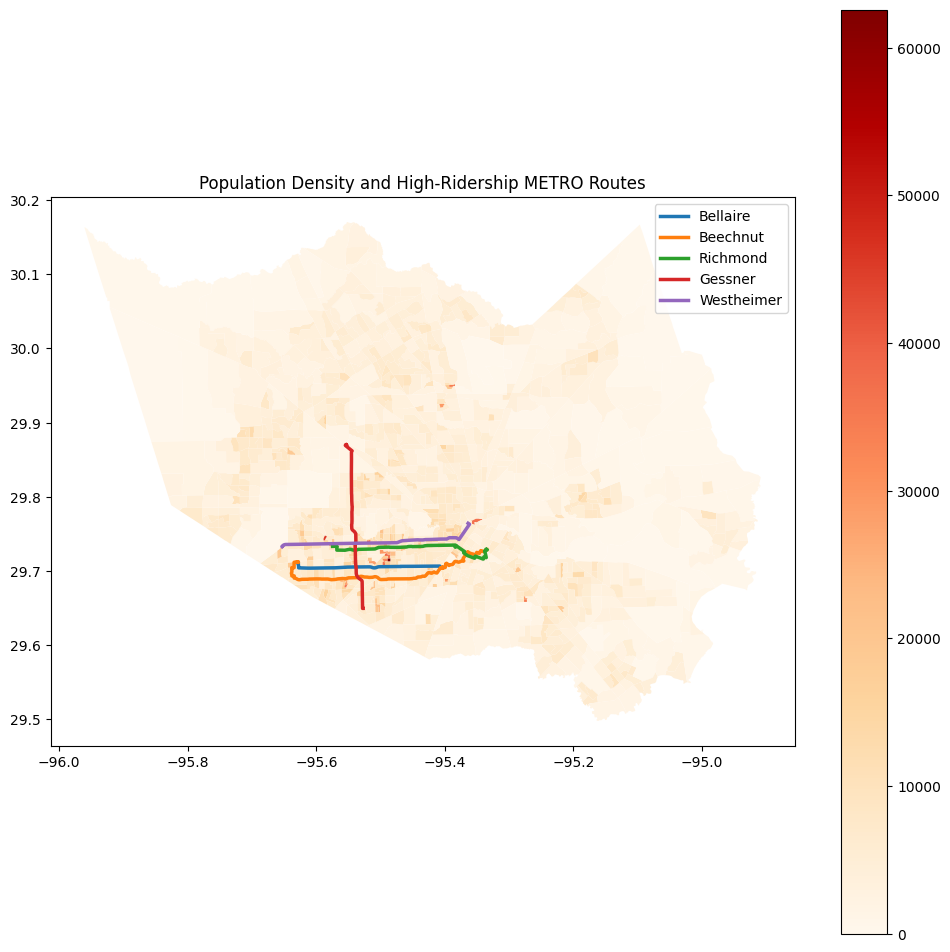

In [7]:
fig, ax = plt.subplots(figsize=(12, 12))

tracts.plot(
    column="pop_density",
    cmap="OrRd",
    legend=True,
    ax=ax,
    linewidth=0
)

for route_name in route_geometry["route_long_name"].unique():
    route = route_geometry[
        route_geometry["route_long_name"] == route_name
    ].sort_values("shape_pt_sequence")

    ax.plot(
        route["shape_pt_lon"],
        route["shape_pt_lat"],
        linewidth=2.5,
        label=route_name
    )

ax.set_title("Population Density and High-Ridership METRO Routes")
ax.legend()
plt.show()

## Supporting Final Analysis

This cell supports the final recommendation workflow by preparing, checking, or displaying final project outputs.

In [ ]:
## Recommendation

Based on this analysis, METRO should prioritize further evaluation of the Westheimer, Beechnut, and Gessner corridors for future service improvements or capital investment. Westheimer represents the strongest overall investment candidate due to its unmatched ridership volume, while Beechnut shows notable efficiency relative to scheduled service. Gessner should be considered strategically because it connects multiple high-demand east-west corridors.

Future analysis should expand this model to all METRO routes, include full-year ridership data, and add route-level demographic exposure using spatial joins between route buffers and Census tracts.

## 6. Save Final Outputs

Final charts or processed datasets are saved for use in the project README, GitHub repository, and future interactive website.

In [9]:
plt.savefig("../data/outputs/final_investment_priority_score.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## 6. Save Final Outputs

Final charts or processed datasets are saved for use in the project README, GitHub repository, and future interactive website.

In [10]:
plt.savefig("../data/outputs/final_density_route_overlay.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

## Key Findings

1. **Westheimer emerges as the strongest overall investment candidate.**  
   It has the highest average weekday ridership among the analyzed routes and remains highly productive relative to scheduled service.

2. **Beechnut shows strong service productivity.**  
   Although it has lower total ridership than Westheimer, it performs strongly when ridership is evaluated against scheduled trips.

3. **Gessner is strategically important as a north-south connector.**  
   It intersects multiple major east-west corridors and may play an important role in network connectivity.

4. **Richmond and Bellaire remain important high-demand corridors.**  
   Their investment scores are lower than Westheimer, Beechnut, and Gessner in this sample, but they continue to show substantial ridership demand.

5. **High-ridership corridors generally overlap with denser areas of Harris County.**  
   This supports the broader project thesis that population density and transit demand should be analyzed together when evaluating investment priorities.


## Final Recommendation

Based on the current analysis, METRO should prioritize further evaluation of the **Westheimer**, **Beechnut**, and **Gessner** corridors for potential service improvements or future capital investment.

Westheimer represents the clearest high-priority corridor because it combines unmatched ridership volume with strong productivity. Beechnut shows strong riders-per-trip performance, suggesting that demand may be high relative to scheduled service. Gessner is important because of its role as a north-south connector across several major east-west corridors.

These recommendations should be interpreted as a first-pass analytical framework rather than a final engineering or planning decision. A full investment study would also need to include operating costs, vehicle capacity, travel time reliability, employment density, equity metrics, and capital project constraints.


## Future Work

Future versions of this project could expand the analysis by:

- Including all METRO bus routes instead of a selected group of high-ridership corridors
- Automating full-year ridership extraction from monthly PDF reports
- Adding employment density and major job centers
- Calculating demographic exposure using route buffers and spatial joins
- Incorporating vehicle ownership, poverty rate, and commute mode data
- Comparing bus corridors against potential BRT or rail expansion scenarios
- Building an interactive React/D3 dashboard for public-facing exploration
